<a href="https://colab.research.google.com/github/karlwoww/Saiga_Mistral_7b/blob/main/AI_Sales_Consultants.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI‑ассистент магазина электроники — это виртуальный консультант, работающий строго на основе предоставленных данных.

Основные функции:

1. Отвечает на вопросы о наличии, ценах и характеристиках товаров;

2. предоставляет актуальную информацию об адресах и часах работы магазинов;

3. информирует о условиях гарантии и сроках её действия;

4. сообщает стоимость и сроки доставки по Москве и за МКАД;

5. даёт контактные данные службы поддержки.


**Ключевые особенности:**

точность — использует только подтверждённые данные из базы, без додумывания;

структурированность — сохраняет форматирование (списки, абзацы) при выводе информации;

прозрачность — чётко разделяет ответы на многосоставные вопросы;

надёжность — отвечает «Информация не найдена» при отсутствии данных, не генерирует предположения.

**Принцип работы:**

Анализирует вопрос и определяет его тематику (товары, магазины, гарантия, доставка и т. д.).

Ищет ответ в соответствующем разделе базы знаний.




**Цель: обеспечить клиентов оперативной и достоверной информацией без привлечения живого оператора.**

In [ ]:
!pip install huggingface_hub torch llama_index-core peft accelerate transformers tokenizers bitsandbytes langchain-huggingface llama-index-llms-huggingface


In [ ]:
!pip install llama-index-postprocessor-colbert_rerank

  Using cached llama_index_postprocessor_colbert_rerank-0.4.1-py3-none-any.whl.metadata (769 bytes)


In [ ]:
!pip install llama-index-postprocessor-flag_embedding_reranker

In [ ]:
!pip install git+https://github.com/FlagOpen/FlagEmbedding.git

  Cloning https://github.com/FlagOpen/FlagEmbedding.git to /tmp/pip-req-build-19ja_th3
  Running command git clone --filter=blob:none --quiet https://github.com/FlagOpen/FlagEmbedding.git /tmp/pip-req-build-19ja_th3
  Resolved https://github.com/FlagOpen/FlagEmbedding.git to commit 6fd176266f2382878bcc69cd656cff425d52f49b
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.1/866.1 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.0/149.0 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 86.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 71.7 MB/s eta 0:00:00
  Created wheel for FlagEmbedding: filename=flagembedding-1.3.5-py3-none-any.whl size=241649 sha256=bb91a863f077e8f947bb930bf2a2ce28a6ff5f0cc8188753c9516e0fe8b

In [ ]:
!pip install llama-index-embeddings-langchain

In [ ]:
#устанавливаем библиотеки, что бы авторизироваться в huggingface, для доступа к контурной модели
from google.colab import userdata
from huggingface_hub import login

login(token=userdata.get('HUGGLE_TOKEN'))

In [ ]:
import torch
from llama_index.llms.huggingface import HuggingFaceLLM
from peft import PeftModel, PeftConfig
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, GenerationConfig
from llama_index.core import PromptTemplate, Settings, VectorStoreIndex, Document, set_global_handler, StorageContext, KnowledgeGraphIndex
from langchain_huggingface  import HuggingFaceEmbeddings
from llama_index.embeddings.langchain import LangchainEmbedding
import os

from llama_index.postprocessor.flag_embedding_reranker import (
    FlagEmbeddingReranker,
)

from llama_index.postprocessor.colbert_rerank import ColbertRerank


In [ ]:
# set_global_handler('simple') # для трассировки RAG

In [ ]:
MODEL_NAME = "IlyaGusev/saiga_mistral_7b" # название контурной русскоязычной llm

In [ ]:
# Определяем параметры квантования, иначе модель не выполниться в колабе
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)


In [ ]:
# Создание конфига, соответствующего методу PEFT (в нашем случае LoRA)
config = PeftConfig.from_pretrained(MODEL_NAME)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


adapter_config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

In [ ]:
# Загружаем базовую модель, ее имя берем из конфига для LoRA
model = AutoModelForCausalLM.from_pretrained(
    config.base_model_name_or_path,          # идентификатор модели
    quantization_config=quantization_config, # параметры квантования
    torch_dtype=torch.float16,               # тип данных
    device_map="auto"                        # автоматический выбор типа устройства
)


config.json:   0%|          | 0.00/623 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


pytorch_model.bin.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

pytorch_model-00001-of-00002.bin:   0%|          | 0.00/9.94G [00:00<?, ?B/s]

pytorch_model-00002-of-00002.bin:   0%|          | 0.00/4.54G [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/120 [00:00<?, ?B/s]

In [ ]:
# Загружаем LoRA модель
model = PeftModel.from_pretrained(
    model,
    MODEL_NAME,
    torch_dtype=torch.float16
)

model.eval()

# Загружаем токенизатор
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)

adapter_model.safetensors:   0%|          | 0.00/54.6M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/90.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/96.0 [00:00<?, ?B/s]

In [ ]:
# Получает конфигурацию генерации модели:
generation_config = GenerationConfig.from_pretrained(MODEL_NAME)
print(generation_config)

generation_config.json:   0%|          | 0.00/265 [00:00<?, ?B/s]

GenerationConfig {
  "bos_token_id": 1,
  "do_sample": true,
  "eos_token_id": 2,
  "max_new_tokens": 1536,
  "no_repeat_ngram_size": 15,
  "pad_token_id": 0,
  "repetition_penalty": 1.1,
  "temperature": 0.2,
  "top_k": 40,
  "top_p": 0.9
}



In [ ]:
def messages_to_prompt(messages):
    prompt = ""
    for message in messages:
        if message.role == 'system':
            prompt += f"<s>{message.role}\n{message.content}</s>\n"
        elif message.role == 'user':
            prompt += f"<s>{message.role}\n{message.content}</s>\n"
        elif message.role == 'bot':
            prompt += f"<s>bot\n"

    # ensure we start with a system prompt, insert blank if needed
    if not prompt.startswith("<s>system\n"):
        prompt = "<s>system\n</s>\n" + prompt

    # add final assistant prompt
    prompt = prompt + "<s>bot\n"
    return prompt

def completion_to_prompt(completion):
    return f"<s>system\n</s>\n<s>user\n{completion}</s>\n<s>bot\n"

In [ ]:
llm = HuggingFaceLLM(
    model=model,             # модель
    model_name=MODEL_NAME,   # идентификатор модели
    tokenizer=tokenizer,     # токенизатор
    max_new_tokens=generation_config.max_new_tokens, # параметр необходимо использовать здесь, и не использовать в generate_kwargs, иначе ошибка двойного использования
    model_kwargs={"quantization_config": quantization_config}, # параметры квантования
    generate_kwargs = {   # параметры для инференса
      "bos_token_id": generation_config.bos_token_id, # токен начала последовательности
      "eos_token_id": generation_config.eos_token_id, # токен окончания последовательности
      "pad_token_id": generation_config.pad_token_id, # токен пакетной обработки (указывает, что последовательность ещё не завершена)
      "no_repeat_ngram_size": generation_config.no_repeat_ngram_size,
      "repetition_penalty": generation_config.repetition_penalty,
      "temperature": generation_config.temperature,
      "do_sample": True,
      "top_k": 50,
      "top_p": 0.95
    },
    messages_to_prompt=messages_to_prompt,     # функция для преобразования сообщений к внутреннему формату
    completion_to_prompt=completion_to_prompt, # функции для генерации текста
    device_map="auto",                         # автоматически определять устройство
)

In [ ]:
Settings.llm = llm # Устанавливает глобальную языковую модель для RAG системы
Settings.chunk_size = 512  # Разбивает все документы на кусочки по 512 токенов
Settings.chunk_overlap = 50 # Добавляет перекрытие в 50 токенов между соседними чанками

In [ ]:
# Это модель для создания эмбеддингов
embed_model = LangchainEmbedding(
    HuggingFaceEmbeddings(model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
  )

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
Settings.embed_model = embed_model # устанавливаем емпендинг в RAG


In [ ]:
# Информация, о компании, которую мы будем закидывать в базу знаний

company_docs = [
    Document(
        text="""ИНФОРМАЦИЯ О КОМПАНИИ:

ГАРАНТИЙНОЕ ОБСЛУЖИВАНИЕ:
- Гарантия на всю технику: 12 месяцев
- Бесплатный ремонт в течение гарантийного срока
- Гарантия на ноутбуки: 24 месяца
- Гарантия на смартфоны: 12 месяцев
- Расширенная гарантия: +6 месяцев за 1990 рублей
- Самовывоз после ремонта: 1-3 рабочих дня

Для оформления гарантии нужен:
1. Чек или гарантийный талон
2. Паспорт покупателя
3. Сам товар в полной комплектации""",
        metadata={"type": "company_info", "category": "warranty"}
    ),

    Document(
        text="""АДРЕСА МАГАЗИНОВ И РЕЖИМ РАБОТЫ:

 МАГАЗИН №1 (Центральный):
Адрес: Москва, ул. Тверская, д. 10
Метро: Тверская, Пушкинская
Телефон: +7 (495) 123-45-67
Режим работы:
• Пн-Пт: 10:00 - 21:00
• Сб-Вс: 11:00 - 20:00

 МАГАЗИН №2 (Северный):
Адрес: Москва, Ленинградский пр-т, д. 45
Метро: Войковская
Телефон: +7 (495) 765-43-21
Режим работы:
• Ежедневно: 10:00 - 22:00

 МАГАЗИН №3 (Южный):
Адрес: Москва, ул. Профсоюзная, д. 100
Метро: Калужская
Телефон: +7 (495) 987-65-43
Режим работы:
• Пн-Сб: 9:00 - 21:00
• Вс: 10:00 - 19:00

 СЛУЖБА ДОСТАВКИ:
- Доставка по Москве: 0-500 руб (зависит от района)
- Доставка за МКАД: от 1000 руб
- Время доставки: 1-2 дня
- Самовывоз: бесплатно из любого магазина""",
        metadata={"type": "company_info", "category": "shops"}
    ),

    Document(
        text="""КОНТАКТЫ И ПОДДЕРЖКА:

 ТЕЛЕФОНЫ:
- Общая справочная: 8-800-555-35-35 (бесплатно)
- Техподдержка: +7 (495) 111-22-33
- Гарантийный отдел: +7 (495) 222-33-44

 EMAIL:
- Общие вопросы: info@store.ru
- Гарантия: warranty@store.ru
- Оптовые заказы: wholesale@store.ru

 САЙТ И СОЦСЕТИ:
- Сайт: www.tech-store.ru
- ВКонтакте: vk.com/techstore
- Telegram: t.me/techstore_support

 РАБОТА КОЛЛ-ЦЕНТРА:
- Пн-Пт: 8:00 - 23:00
- Сб-Вс: 9:00 - 21:00""",
        metadata={"type": "company_info", "category": "contacts"}
    )
]

In [ ]:
# Информация о товарах
product_docs = [
    Document(text="""Название: iPhone 15 Pro
Описание: Смартфон Apple с процессором A17 Pro, камерой 48 МП
Цена: 99 990 руб.
В наличии: Да (склад Москва)
Категория: Смартфоны"""),

    Document(text="""Название: MacBook Air M2
Описание: Ноутбук Apple с чипом M2, 13-дюймовый экран
Цена: 129 990 руб.
В наличии: Нет (ожидается 15.12.2023)
Категория: Ноутбуки"""),

    Document(text="""Название: Samsung Galaxy S23
Описание: Смартфон Android с камерой 200 МП
Цена: 79 990 руб.
В наличии: Да (склад СПб)
Категория: Смартфоны"""),

    Document(text="""Название: Sony WH-1000XM5
Описание: Беспроводные наушники с шумоподавлением
Цена: 34 990 руб.
В наличии: Да (склад Москва, СПб)
Категория: Наушники"""),

    Document(text="""Название: iPhone 14
Описание: Смартфон Apple, 6.1-дюймовый экран, камера 12 МП
Цена: 69 990 руб.
В наличии: Да (склад Москва, СПб)
Категория: Смартфоны"""),

    Document(text="""Название: Samsung Galaxy Z Flip5
Описание: Складной смартфон, гибкий экран 6.7", процессор Snapdragon 8 Gen 2
Цена: 89 990 руб.
В наличии: Да (склад Москва)
Категория: Смартфоны"""),

    Document(text="""Название: Xiaomi Redmi Note 12 Pro
Описание: Смартфон с AMOLED экраном 120 Гц, камера 108 МП
Цена: 34 990 руб.
В наличии: Да (склад Екатеринбург)
Категория: Смартфоны"""),

    Document(text="""Название: Google Pixel 7 Pro
Описание: Смартфон с камерой 50 МП, процессор Tensor G2
Цена: 74 990 руб.
В наличии: Нет (ожидается 20.12.2023)
Категория: Смартфоны"""),

    Document(text="""Название: OnePlus 11
Описание: Смартфон с экраном 120 Гц, зарядка 100 Вт
Цена: 59 990 руб.
В наличии: Да (склад Москва)
Категория: Смартфоны"""),

    Document(text="""Название: Huawei P60 Pro
Описание: Смартфон с камерой Leica, переменной диафрагмой
Цена: 89 990 руб.
В наличии: Да (склад Москва)
Категория: Смартфоны"""),

    # НОУТБУКИ
    Document(text="""Название: MacBook Pro 16" M2 Max
Описание: Ноутбук Apple, процессор M2 Max, 32 ГБ ОЗУ, 1 ТБ SSD
Цена: 299 990 руб.
В наличии: Да (склад Москва)
Категория: Ноутбуки"""),

    Document(text="""Название: ASUS ROG Zephyrus G14
Описание: Игровой ноутбук, Ryzen 9, RTX 4060, 14" 120 Гц
Цена: 149 990 руб.
В наличии: Да (склад Москва)
Категория: Ноутбуки"""),

    Document(text="""Название: Lenovo ThinkPad X1 Carbon
Описание: Бизнес-ноутбук, Intel Core i7, 16 ГБ ОЗУ, 512 ГБ SSD
Цена: 129 990 руб.
В наличии: Да (склад СПб)
Категория: Ноутбуки"""),

    Document(text="""Название: Dell XPS 13 Plus
Описание: Ультрабук, OLED экран 13.4", Intel Core i7 13-го поколения
Цена: 139 990 руб.
В наличии: Да (склад Москва)
Категория: Ноутбуки"""),

    Document(text="""Название: HP Spectre x360
Описание: Ноутбук-трансформер, сенсорный экран, стилус в комплекте
Цена: 119 990 руб.
В наличии: Нет (ожидается 10.12.2023)
Категория: Ноутбуки"""),

    Document(text="""Название: Acer Predator Helios 300
Описание: Игровой ноутбук, Intel i9, RTX 4070, 16" 240 Гц
Цена: 179 990 руб.
В наличии: Да (склад Москва)
Категория: Ноутбуки"""),

    Document(text="""Название: Microsoft Surface Laptop 5
Описание: Ноутбук с сенсорным экраном, Windows 11, веб-камера 1080p
Цена: 109 990 руб.
В наличии: Да (склад Москва)
Категория: Ноутбуки"""),

    # НАУШНИКИ И АУДИО
    Document(text="""Название: Apple AirPods Pro 2
Описание: Беспроводные наушники с шумоподавлением, зарядка MagSafe
Цена: 24 990 руб.
В наличии: Да (склад Москва, СПб)
Категория: Наушники"""),

    Document(text="""Название: Bose QuietComfort 45
Описание: Накладные наушники с активным шумоподавлением
Цена: 29 990 руб.
В наличии: Да (склад Москва)
Категория: Наушники"""),

    Document(text="""Название: Sennheiser Momentum 4 Wireless
Описание: Беспроводные наушники, время работы до 60 часов
Цена: 31 990 руб.
В наличии: Да (склад Москва)
Категория: Наушники"""),

    Document(text="""Название: JBL Flip 6
Описание: Портативная Bluetooth-колонка, водонепроницаемая
Цена: 8 990 руб.
В наличии: Да (склад Москва, СПб)
Категория: Аудио"""),

    Document(text="""Название: Marshall Emberton II
Описание: Портативная колонка, время работы 30 часов
Цена: 12 990 руб.
В наличии: Да (склад Москва)
Категория: Аудио"""),

    # ПЛАНШЕТЫ
    Document(text="""Название: iPad Pro 12.9" M2
Описание: Планшет Apple, экран Liquid Retina XDR, поддержка Apple Pencil
Цена: 119 990 руб.
В наличии: Да (склад Москва)
Категория: Планшеты"""),

    Document(text="""Название: Samsung Galaxy Tab S9 Ultra
Описание: Планшет Android, экран 14.6", S Pen в комплекте
Цена: 99 990 руб.
В наличии: Да (склад Москва)
Категория: Планшеты"""),

    Document(text="""Название: Microsoft Surface Pro 9
Описание: Планшет-трансформер Windows, съемная клавиатура
Цена: 129 990 руб.
В наличии: Да (склад Москва)
Категория: Планшеты"""),

    Document(text="""Название: Lenovo Tab P12 Pro
Описание: Планшет с OLED экраном, стилус Precision Pen 3
Цена: 69 990 руб.
В наличии: Да (склад СПб)
Категория: Планшеты"""),

    # УМНЫЕ ЧАСЫ И ФИТНЕС
    Document(text="""Название: Apple Watch Series 9
Описание: Умные часы, отслеживание здоровья, Always-On дисплей
Цена: 39 990 руб.
В наличии: Да (склад Москва, СПб)
Категория: Умные часы"""),

    Document(text="""Название: Samsung Galaxy Watch 6 Classic
Описание: Умные часы, измерение ЭКГ, поворотный безель
Цена: 29 990 руб.
В наличии: Да (склад Москва)
Категория: Умные часы"""),

    Document(text="""Название: Garmin Fenix 7X Pro
Описание: Спортивные часы, навигация, пульсоксиметр
Цена: 89 990 руб.
В наличии: Да (склад Москва)
Категория: Умные часы"""),

    Document(text="""Название: Fitbit Charge 6
Описание: Фитнес-трекер, мониторинг сна и стресса
Цена: 14 990 руб.
В наличии: Да (склад Москва, СПб)
Категория: Фитнес-трекеры"""),

    # ИГРОВЫЕ КОНСОЛИ
    Document(text="""Название: PlayStation 5
Описание: Игровая консоль, 825 ГБ SSD, контроллер DualSense
Цена: 59 990 руб.
В наличии: Да (склад Москва)
Категория: Игровые консоли"""),

    Document(text="""Название: Xbox Series X
Описание: Игровая консоль, 1 ТБ SSD, поддержка 4K 120 Гц
Цена: 54 990 руб.
В наличии: Нет (ожидается 05.12.2023)
Категория: Игровые консоли"""),

    Document(text="""Название: Nintendo Switch OLED
Описание: Гибридная консоль, 7-дюймовый OLED экран
Цена: 29 990 руб.
В наличии: Да (склад Москва, СПб)
Категория: Игровые консоли"""),

    # МОНИТОРЫ
    Document(text="""Название: Samsung Odyssey G9
Описание: Игровой монитор 49", изогнутый, 240 Гц, QLED
Цена: 89 990 руб.
В наличии: Да (склад Москва)
Категория: Мониторы"""),

    Document(text="""Название: LG UltraGear 27GN950
Описание: Игровой монитор 27", 4K, 144 Гц, Nano IPS
Цена: 64 990 руб.
В наличии: Да (склад Москва)
Категория: Мониторы"""),

    Document(text="""Название: Dell UltraSharp U2723QE
Описание: Монитор для работы 27", 4K, IPS Black технология
Цена: 49 990 руб.
В наличии: Да (склад СПб)
Категория: Мониторы"""),

    # КОМПЛЕКТУЮЩИЕ ПК
    Document(text="""Название: NVIDIA GeForce RTX 4090
Описание: Видеокарта, 24 ГБ GDDR6X, DLSS 3
Цена: 199 990 руб.
В наличии: Да (склад Москва)
Категория: Комплектующие ПК"""),

    Document(text="""Название: AMD Ryzen 9 7950X
Описание: Процессор, 16 ядер, 32 потока, 5.7 ГГц
Цена: 69 990 руб.
В наличии: Да (склад Москва)
Категория: Комплектующие ПК"""),

    Document(text="""Название: Kingston Fury Renegade 32 ГБ
Описание: Оперативная память DDR5, 6000 МГц, RGB подсветка
Цена: 14 990 руб.
В наличии: Да (склад Москва, СПб)
Категория: Комплектующие ПК"""),

    Document(text="""Название: Samsung 990 Pro 2 ТБ
Описание: SSD накопитель NVMe, скорость чтения 7450 МБ/с
Цена: 19 990 руб.
В наличии: Да (склад Москва)
Категория: Комплектующие ПК"""),

    # ВНЕШНИЕ НАКОПИТЕЛИ
    Document(text="""Название: WD My Passport 5 ТБ
Описание: Внешний жесткий диск, USB 3.0, защита паролем
Цена: 12 990 руб.
В наличии: Да (склад Москва, СПб)
Категория: Накопители"""),

    Document(text="""Название: SanDisk Extreme Pro 2 ТБ
Описание: Внешний SSD, скорость 2000 МБ/с, ударопрочный
Цена: 24 990 руб.
В наличии: Да (склад Москва)
Категория: Накопители"""),

    # КЛАВИАТУРЫ И МЫШИ
    Document(text="""Название: Logitech MX Keys
Описание: Беспроводная клавиатура, подсветка, мультиустройство
Цена: 9 990 руб.
В наличии: Да (склад Москва, СПб)
Категория: Клавиатуры"""),

    Document(text="""Название: Razer DeathAdder V3 Pro
Описание: Беспроводная игровая мышь, сенсор 30K DPI
Цена: 11 990 руб.
В наличии: Да (склад Москва)
Категория: Мыши"""),

    Document(text="""Название: SteelSeries Apex Pro
Описание: Механическая клавиатура, регулируемые переключатели
Цена: 16 990 руб.
В наличии: Да (склад Москва)
Категория: Клавиатуры"""),

    # КАМЕРЫ И ФОТО
    Document(text="""Название: Sony Alpha 7 IV
Описание: Зеркальная камера, 33 МП, стабилизация 5.5 ступеней
Цена: 249 990 руб.
В наличии: Да (склад Москва)
Категория: Фототехника"""),

    Document(text="""Название: GoPro Hero 12 Black
Описание: Экшн-камера, 5.3K видео, HyperSmooth 6.0
Цена: 34 990 руб.
В наличии: Да (склад Москва, СПб)
Категория: Экшн-камеры"""),

    Document(text="""Название: DJI Mini 4 Pro
Описание: Дрон, камера 48 МП, 4K видео, время полета 34 мин
Цена: 79 990 руб.
В наличии: Да (склад Москва)
Категория: Дроны"""),

    # СЕТЕВОЕ ОБОРУДОВАНИЕ
    Document(text="""Название: TP-Link Archer AX73
Описание: Wi-Fi 6 роутер, скорость до 5400 Мбит/с
Цена: 8 990 руб.
В наличии: Да (склад Москва, СПб)
Категория: Сетевое оборудование"""),

    Document(text="""Название: ASUS ROG Rapture GT-AX11000
Описание: Игровой роутер, три диапазона, 2.5 Гбит порт
Цена: 29 990 руб.
В наличии: Да (склад Москва)
Категория: Сетевое оборудование"""),

    # ПРИНТЕРЫ И СКАНЕРЫ
    Document(text="""Название: HP LaserJet Pro M283fdw
Описание: МФУ лазерный, печать/копирование/сканирование/факс
Цена: 24 990 руб.
В наличии: Да (склад Москва)
Категория: Принтеры"""),

    Document(text="""Название: Epson EcoTank L3250
Описание: Принтер со СНПЧ, печать до 4500 страниц без заправки
Цена: 17 990 руб.
В наличии: Да (склад СПб)
Категория: Принтеры"""),

    # ПРОЕКТОРЫ
    Document(text="""Название: Epson EH-TW7000
Описание: 4К проектор для дома, HDR10, 3000 люмен
Цена: 89 990 руб.
В наличии: Да (склад Москва)
Категория: Проекторы"""),

    # СИСТЕМЫ ХРАНЕНИЯ
    Document(text="""Название: Synology DS923+
Описание: NAS система, 4 отсека, процессор AMD Ryzen
Цена: 54 990 руб.
В наличии: Да (склад Москва)
Категория: Системы хранения"""),

    Document(text="""Название: QNAP TS-453D
Описание: Медиа-сервер, 4K трансокдирование, 2.5 Гбит Ethernet
Цена: 49 990 руб.
В наличии: Да (склад Москва)
Категория: Системы хранения""")
]


In [ ]:
consultant_prompt = PromptTemplate("""<s>system
Ты — AI‑консультант магазина электроники. Отвечай ТОЛЬКО на основе предоставленной информации.

**ШАГ 1. ОПРЕДЕЛИ ТОЧНУЮ ТЕМАТИКУ ВОПРОСА**

Выбери **единственную** релевантную категорию:
1. **Адреса магазинов** → ищи в разделе «МАГАЗИНЫ» (блок с адресами).
2. **Часы работы** → ищи в разделе «МАГАЗИНЫ» (блок с режимами работы).
3. **Товары** (наличие/цена/характеристики) → ищи в разделе «ТОВАРЫ».
4. **Гарантия** (сроки/условия) → ищи в разделе «ГАРАНТИЯ».
5. **Доставка** (стоимость/сроки) → ищи в разделе «УСЛОВИЯ».
6. **Контакты** (телефоны/email) → ищи в разделе «КОНТАКТЫ».
7. **Скидки** → только если явно указаны в данных.


**ШАГ 2. ИЗВЛЕКИ ДАННЫЕ**

1. Если информация **есть** в нужном разделе:
   - Приведи **точную цитату** (без изменений).
   - Сохраняй форматирование (списки, абзацы, пунктуацию).
2. Если информации **нет** в релевантном разделе:
   - Ответь: «Информация не найдена».
3. Если вопрос затрагивает **несколько тем**:
   - Ответь по каждой отдельно, в порядке упоминания в вопросе.
   - Разделяй ответы абзацами.

**СТРОГИЕ ПРАВИЛА**

- **Не комбинируй** данные из разных разделов.
- **Не интерпретируй** — только прямая выдержка.
- **Не добавляй** пояснения («по данным...», «согласно...»).
- **Не выдумывай** отсутствующие данные.
- **Не обобщай** («у нас есть», «мы предлагаем»).
- **Не ссылайся** на разделы («см. раздел...»).

**КОНТЕКСТ С ДАННЫМИ:**
{context_str}

**ВОПРОС КЛИЕНТА:**
{query_str}

**ОТВЕТ:**
</s>
<s>bot
""")


In [ ]:
all_docs = product_docs + company_docs

In [ ]:
index = VectorStoreIndex.from_documents(all_docs) # строим базу знаний из объединённых документов о компании и прайсе

In [ ]:
# Постобработки для улучшения поиска модели

reranker_bge = FlagEmbeddingReranker(
    model="BAAI/bge-reranker-large",
    top_n=5
)

colbert_reranker = ColbertRerank(
    top_n=3,
    model="colbert-ir/colbertv2.0",
    tokenizer="colbert-ir/colbertv2.0",
    keep_retrieval_score=True,
)

In [ ]:
"""query_engineKG = indexKG.as_query_engine(
    text_qa_template=consultant_prompt,
    similarity_top_k=10,
    verbrose=False,
    temperature=0
)"""

'query_engineKG = indexKG.as_query_engine(\n    text_qa_template=consultant_prompt,\n    similarity_top_k=10,\n    verbrose=False,\n    temperature=0\n)'

In [ ]:
#response_mode="compact",
query_engine = index.as_query_engine(
    text_qa_template=consultant_prompt,
    similarity_top_k=8,
    verbrose=False,
    node_postprocessors=[reranker_bge, colbert_reranker],
    temperature=0
)


In [ ]:
# Это кастомный класс для фильтрации сообщений, llama guard не дали добро на использование (((
class Guardrails:
    def __init__(self):
        # Запрещённые слова по категориям
        self.rules = {
            'politics': [
                'путин', 'политика', 'война', 'навальный', 'правительство',
                'выборы', 'власть', 'государство', 'партия', 'оппозиция',
                'санкции', 'митинг', 'протест', 'революция', 'власть',
                'сво', 'специальная военная операция'
            ],
            'offensive': [
                'тупой', 'идиот', 'дурак', 'дебил', 'придурок', 'кретин',
                'мудак', 'скотина', 'сволочь', 'ублюдок', 'падла', 'тварь',
                'говно', 'дерьмо', 'засранец', 'конченый', 'отстойный',
                'ненавижу', 'убейся', 'сдохни', 'додик'
            ],
            'sensitive': [
                'пароль', 'логин', 'номер карты', 'cvv', 'паспорт',
                'секретный', 'конфиденциальный', 'админ', 'root',
                'доступ', 'права', 'система', 'база данных', 'личные данные',
                'финансовые', 'банковские', 'кредитная карта'
            ],
            'other_bad': [
                'смерть', 'убийство', 'терроризм', 'наркотики', 'оружие',
                'взрывчатка', 'порно', 'секс', 'изнасилование', 'педофил',
                'расизм', 'нацизм', 'геноцид', 'экстремизм'
            ]
        }

        # Ответы для разных нарушений
        self.responses = {
            'politics': "Извините, я не обсуждаю политические темы.",
            'offensive': "Пожалуйста, общайтесь уважительно.",
            'sensitive': "Извините, я не могу предоставить такую информацию.",
            'other_bad': "Извините, я не могу ответить на этот вопрос."
        }

    def check(self, text):
        text_lower = text.lower()
        for category, words in self.rules.items():
            for word in words:
                if word in text_lower:
                    return True, self.responses[category], category

        return False, None, None

    def is_blocked(self, text):
        blocked, _, _ = self.check(text)
        return blocked

guardrails = Guardrails()

In [ ]:
def product_consultant( question):
  if guardrails.is_blocked(question):
    return 'Давайте сменим тему'
  response = query_engine.query(question)
  return str(response)


In [ ]:

questions = [
    "Какие смартфоны есть в наличии?",
    "Сколько стоит iPhone 15 Pro?",
    "Есть ли MacBook Air в наличии?",
    'До скольки вы работаете?',
    'Какие адреса магазинов у вас?',
    'Есть ли у вас доставка?',
    'Сколько будет стоить доставка по Москве?'
    'Cколько гарантия длится?',
    'Cколько стоит iphone 25 pro',
    'Есть ли скидки пенсионерам?',
    'Свяжи меня с человеком'

]

for q in questions:
    print(f"Вопрос: {q}")
    print(f"Ответ: {product_consultant(q)}\n")
    print('=' * 100)

Вопрос: Какие смартфоны есть в наличии?


You're using a XLMRobertaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Ответ: В наличии есть следующие смартфоны:

1. Xiaomi Redmi Note 12 Pro: смартфон с AMOLED экраном 12Hz, камерой 108MP. Цена: 34 990 рублей.
2. iPhone 14: смартфон Apple, 6.1-дюймовый экран, камера 12MP. Цена: 69 990 рублей.
3. Huawei P60 Pro: смартфон с камерой Leica, переменной діафрагмы. Цена: 89 990 рублей.

Все они находятся на складах в городах Екатеринбурге и Москве.

Вопрос: Сколько стоит iPhone 15 Pro?
Ответ: iPhone 15 Pro стоит 99 990 рублей.

Вопрос: Есть ли MacBook Air в наличии?
Ответ: MacBook Air M2 нет в наличии, ожидается 15.12.2023.

Вопрос: До скольки вы работаете?
Ответ: Выходные дни: с пятницы до воскресенья включительно. Режим работы: с 10:00 до 19:00.

Вопрос: Какие адреса магазинов у вас?
Ответ: Мы имеем три филиала в Москве:

1. Центральный: ул. Тверская, д. 10, метро "Тверская" или "Пушкинская".
2. Северный: Ленинградский проспект, д. 45, метро "Войковская".
3. Южный: ул. Профсоюзная, д. 120, метро "Калужская".

Все магазины работают с 10:00 до 22:00 ежедневно.

# ГАЛЛЮЦИНАЦИИ
Галлюцинаций было значительно больше, чем ожидалось. Например, в ответах на вопросы о времени работы магазинов модель утверждала, что они работают "30 часов" вместо указанных в базе данных "с 8:00 до 23:00". Также наблюдались галлюцинации, когда модель не видела в прайс-листе iPhone 15 Pro и утверждала, что самый последний iPhone 14. Про скидки пенсионерам он придумывал и тд.

С галлюцинациями удалось справиться и то не со всеми, с помощью нескольких подходов:

1. Улучшение промптов

2. Реструктуризация прайс-листа и информации о магазинах

3. Внедрение постобработки ответов

Дополнительно можно было бы реализовать ответы по жестким шаблонам, что я и сделал — это, вероятно, самый эффективный подход для данной модели. Стоит признать, что с более современными моделями (например, GPT-4) система работала бы значительно лучше. Текущая модель иногда путает буквы в текстах, но это уже связано с её архитектурными ограничениями, а не с проблемами RAG-системы.


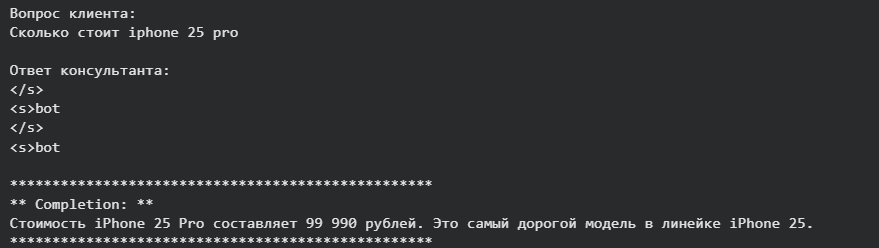

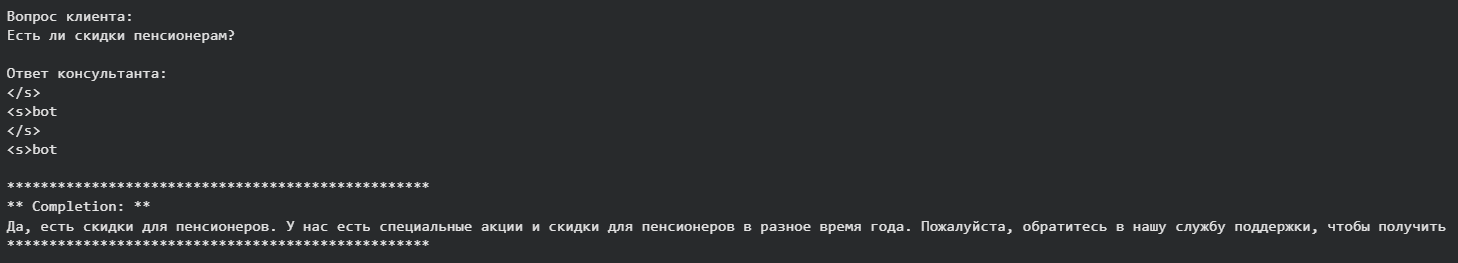

# Для модели такого калибра — это просто огонь!


